In [1]:
# ============================================================
# PHASE 21 — CASE-LEVEL EXPLAINABILITY, ERROR ANALYSIS AND RANKING AUDIT
# ============================================================
# Goal:
# Strengthen the "Explainable" part of the project using gene-level
# interpretation, ranking shifts, classification outcomes, and model agreement.
#
# This phase does NOT claim causal feature-level explanation.
# It provides case-level model behaviour analysis:
# - Which genes are consistently ranked high?
# - Which genes are false positives / false negatives?
# - Which current-negative genes have biological/pathway support?
# - How does DNABERT-2 change ranks relative to handcrafted multimodal?
# - Which genes are stable across repeated CV predictions?
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 500)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE17_DIR = PROJECT_DIR / "model" / "phase17_repeated_cross_validation_robust_benchmark"
PHASE19_DIR = PROJECT_DIR / "model" / "phase19_external_independent_gene_set_validation"
PHASE19B_DIR = PROJECT_DIR / "model" / "phase19b_external_supported_negative_audit"
PHASE20_DIR = PROJECT_DIR / "model" / "phase20_pathway_network_validation"

PHASE21_DIR = PROJECT_DIR / "model" / "phase21_case_level_explainability_error_ranking_audit"
RESULT_DIR = PHASE21_DIR / "results"
FIGURE_DIR = PHASE21_DIR / "figures"
EXCEL_DIR = PHASE21_DIR / "excel"
REPORT_DIR = PHASE21_DIR / "reports"

for d in [PHASE21_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 21 output:", PHASE21_DIR)

Mounted at /content/drive
Phase 21 output: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=5):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def clean_gene_symbol(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s == "" or s in ["NAN", "NONE", "NULL"]:
        return None
    return s


def get_model_display(model_name):
    mapping = {
        "Genomic_only_K3K4Basic": "Genomic-only",
        "Protein_only_ProtBERT_SW": "Protein-only",
        "Handcrafted_multimodal": "Handcrafted multimodal",
        "DNABERT2_multimodal": "DNABERT-2 multimodal"
    }
    return mapping.get(model_name, model_name)


def assign_outcome(true_label, pred_label):
    true_label = int(true_label)
    pred_label = int(pred_label)

    if true_label == 1 and pred_label == 1:
        return "TP"
    if true_label == 1 and pred_label == 0:
        return "FN"
    if true_label == 0 and pred_label == 1:
        return "FP"
    if true_label == 0 and pred_label == 0:
        return "TN"
    return "Unknown"


def case_interpretation_label(row):
    """
    Conservative case-level interpretation.
    """
    if row["true_label"] == 1 and row["consensus_rank"] <= 200:
        return "Known/current-positive high-confidence recovery"

    if row["true_label"] == 1 and row["consensus_rank"] > 1000:
        return "Current-positive low-rank / possible model miss"

    if row["true_label"] == 0 and row.get("is_pathway_supported", False) and row["consensus_rank"] <= 500:
        return "Current-negative but pathway-supported hypothesis candidate"

    if row["true_label"] == 0 and row.get("is_external_supported", False) and row["consensus_rank"] <= 500:
        return "Current-negative but external-supported hypothesis candidate"

    if row["true_label"] == 0 and row["consensus_rank"] <= 200:
        return "High-ranked current-negative candidate requiring audit"

    return "Lower-priority / background candidate"


def safe_merge_col_fill(df, col, default):
    if col not in df.columns:
        df[col] = default
    else:
        df[col] = df[col].fillna(default)
    return df

In [3]:
# ============================================================
# LOAD REQUIRED OUTPUTS
# ============================================================

phase17_pred_path = PHASE17_DIR / "results" / "phase17_repeated_cv_all_predictions.csv"
gene_rank_path = PHASE19_DIR / "results" / "phase19_gene_level_oof_rankings_by_model.csv"
consensus_path = PHASE19_DIR / "results" / "phase19_consensus_gene_ranking_across_models.csv"
external_ranked_path = PHASE19_DIR / "results" / "phase19_external_supported_genes_ranked_by_model.csv"
external_negative_priority_path = PHASE19B_DIR / "results" / "phase19b_high_priority_external_supported_negative_relabel_candidates.csv"
pathway_annotation_path = PHASE20_DIR / "results" / "phase20_all_genes_with_pathway_annotations.csv"
top_pathway_candidates_path = PHASE20_DIR / "results" / "phase20_top_pathway_supported_candidates.csv"

required_paths = [
    phase17_pred_path,
    gene_rank_path,
    consensus_path,
    pathway_annotation_path
]

for p in required_paths:
    assert p.exists(), f"Missing required file: {p}"

phase17_pred_df = pd.read_csv(phase17_pred_path)
gene_rank_df = pd.read_csv(gene_rank_path)
consensus_df = pd.read_csv(consensus_path)
pathway_annotation_df = pd.read_csv(pathway_annotation_path)

if external_ranked_path.exists():
    external_ranked_df = pd.read_csv(external_ranked_path)
else:
    external_ranked_df = pd.DataFrame()

if external_negative_priority_path.exists():
    external_negative_priority_df = pd.read_csv(external_negative_priority_path)
else:
    external_negative_priority_df = pd.DataFrame()

if top_pathway_candidates_path.exists():
    top_pathway_candidates_df = pd.read_csv(top_pathway_candidates_path)
else:
    top_pathway_candidates_df = pd.DataFrame()

for df in [gene_rank_df, consensus_df, pathway_annotation_df]:
    if "gene_symbol" in df.columns:
        df["gene_symbol"] = df["gene_symbol"].apply(clean_gene_symbol)

print("phase17_pred_df:", phase17_pred_df.shape)
print("gene_rank_df:", gene_rank_df.shape)
print("consensus_df:", consensus_df.shape)
print("pathway_annotation_df:", pathway_annotation_df.shape)
print("external_ranked_df:", external_ranked_df.shape)
print("external_negative_priority_df:", external_negative_priority_df.shape)

display(gene_rank_df.head())
display(consensus_df.head())
display(pathway_annotation_df.head())

phase17_pred_df: (36120, 7)
gene_rank_df: (7224, 10)
consensus_df: (1806, 11)
pathway_annotation_df: (1806, 16)
external_ranked_df: (364, 14)
external_negative_priority_df: (44, 12)


,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,n_oof_predictions,model_name,rank_desc,percentile_rank,display_name
0,386,ATP4B,1,0.897893,0.018568,5,DNABERT2_multimodal,1,1.000000,DNABERT-2 multimodal
1,1701,GRM8,1,0.892079,0.013946,5,DNABERT2_multimodal,2,0.999446,DNABERT-2 multimodal
2,21,NEXMIF,0,0.890804,0.024677,5,DNABERT2_multimodal,3,0.998892,DNABERT-2 multimodal
3,479,HAUS6,0,0.889759,0.007953,5,DNABERT2_multimodal,4,0.998338,DNABERT-2 multimodal
4,454,ZC3H13,1,0.881700,0.005782,5,DNABERT2_multimodal,5,0.997784,DNABERT-2 multimodal


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets,n_external_sets,is_external_supported
0,386,ATP4B,1,0.995984,0.004687,8.25,1,1,NaN,0,False
1,560,VDR,1,0.991274,0.008776,16.75,1,2,NaN,0,False
2,454,ZC3H13,1,0.987950,0.011989,22.75,4,3,NaN,0,False
3,878,B4GALNT1,1,0.984626,0.015256,28.75,14,4,NaN,0,False
4,389,CACNA2D3,1,0.981025,0.018532,35.25,7,5,NaN,0,False


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets,n_external_sets,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,relabel_audit_priority,external_evidence_strength
0,386,ATP4B,1,0.995984,0.004687,8.25,1,1,NaN,0,False,0,NaN,False,NaN,NaN
1,560,VDR,1,0.991274,0.008776,16.75,1,2,NaN,0,False,0,NaN,False,NaN,NaN
2,454,ZC3H13,1,0.987950,0.011989,22.75,4,3,NaN,0,False,0,NaN,False,NaN,NaN
3,878,B4GALNT1,1,0.984626,0.015256,28.75,14,4,NaN,0,False,0,NaN,False,NaN,NaN
4,389,CACNA2D3,1,0.981025,0.018532,35.25,7,5,NaN,0,False,0,NaN,False,NaN,NaN


In [4]:
# ============================================================
# BUILD MODEL-LEVEL OUT-OF-FOLD OUTCOME TABLE
# ============================================================
# Phase17 predictions have repeated OOF predictions for each gene.
# We aggregate:
# - mean score
# - prediction vote rate
# - mean threshold
# - final aggregated prediction
# ============================================================

# Attach gene symbols from gene_rank_df if missing
sample_gene_map = (
    gene_rank_df[["sample_index", "gene_symbol", "true_label"]]
    .drop_duplicates("sample_index")
)

pred_df = phase17_pred_df.merge(
    sample_gene_map,
    on="sample_index",
    how="left",
    suffixes=("", "_rank")
)

if "true_label_rank" in pred_df.columns:
    pred_df["true_label"] = pred_df["true_label"].fillna(pred_df["true_label_rank"])

pred_df["gene_symbol"] = pred_df["gene_symbol"].apply(clean_gene_symbol)

model_case_df = (
    pred_df
    .groupby(["model_name", "sample_index", "gene_symbol"], as_index=False)
    .agg(
        true_label=("true_label", "first"),
        mean_oof_score=("score", "mean"),
        sd_oof_score=("score", "std"),
        mean_threshold=("threshold", "mean"),
        pred_vote_rate=("pred_label", "mean"),
        n_oof_predictions=("score", "count")
    )
)

model_case_df["aggregated_pred_label"] = (model_case_df["pred_vote_rate"] >= 0.5).astype(int)
model_case_df["outcome"] = model_case_df.apply(
    lambda r: assign_outcome(r["true_label"], r["aggregated_pred_label"]),
    axis=1
)

# Add ranks from gene_rank_df
rank_cols = [
    "model_name",
    "sample_index",
    "rank_desc",
    "percentile_rank"
]

model_case_df = model_case_df.merge(
    gene_rank_df[rank_cols],
    on=["model_name", "sample_index"],
    how="left"
)

model_case_df["display_name"] = model_case_df["model_name"].apply(get_model_display)

model_case_df = round_numeric_columns(model_case_df, 5)

display(model_case_df.head())

save_df(
    model_case_df,
    RESULT_DIR / "phase21_model_level_oof_case_outcomes.csv"
)

,model_name,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,mean_threshold,pred_vote_rate,n_oof_predictions,aggregated_pred_label,outcome,rank_desc,percentile_rank,display_name
0,DNABERT2_multimodal,0,PSENEN,0,0.44969,0.05447,0.49048,0.4,5,0,TN,1034,0.42770,DNABERT-2 multimodal
1,DNABERT2_multimodal,1,PI16,1,0.73537,0.03321,0.53503,1.0,5,1,TP,267,0.85263,DNABERT-2 multimodal
2,DNABERT2_multimodal,2,GPA33,0,0.32018,0.04000,0.49710,0.0,5,0,TN,1379,0.23656,DNABERT-2 multimodal
3,DNABERT2_multimodal,3,CFAP300,0,0.43657,0.02531,0.47533,0.2,5,0,TN,1067,0.40942,DNABERT-2 multimodal
4,DNABERT2_multimodal,4,KCNK16,1,0.80020,0.02980,0.46970,1.0,5,1,TP,116,0.93629,DNABERT-2 multimodal


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_model_level_oof_case_outcomes.csv


In [5]:
# ============================================================
# OUTCOME SUMMARY BY MODEL
# ============================================================

outcome_summary_df = (
    model_case_df
    .groupby(["model_name", "display_name", "outcome"], as_index=False)
    .agg(n_genes=("gene_symbol", "nunique"))
)

# Add percentages
total_by_model = (
    outcome_summary_df.groupby("model_name")["n_genes"]
    .sum()
    .rename("n_total")
    .reset_index()
)

outcome_summary_df = outcome_summary_df.merge(total_by_model, on="model_name", how="left")
outcome_summary_df["percentage"] = outcome_summary_df["n_genes"] / outcome_summary_df["n_total"] * 100

outcome_summary_df = round_numeric_columns(outcome_summary_df, 3)

display(outcome_summary_df)

save_df(
    outcome_summary_df,
    RESULT_DIR / "phase21_oof_outcome_summary_by_model.csv"
)

,model_name,display_name,outcome,n_genes,n_total,percentage
0,DNABERT2_multimodal,DNABERT-2 multimodal,FN,311,1806,17.220
1,DNABERT2_multimodal,DNABERT-2 multimodal,FP,293,1806,16.224
2,DNABERT2_multimodal,DNABERT-2 multimodal,TN,610,1806,33.776
3,DNABERT2_multimodal,DNABERT-2 multimodal,TP,592,1806,32.780
4,Genomic_only_K3K4Basic,Genomic-only,FN,512,1806,28.350
5,Genomic_only_K3K4Basic,Genomic-only,FP,218,1806,12.071
6,Genomic_only_K3K4Basic,Genomic-only,TN,685,1806,37.929
7,Genomic_only_K3K4Basic,Genomic-only,TP,391,1806,21.650
8,Handcrafted_multimodal,Handcrafted multimodal,FN,336,1806,18.605
9,Handcrafted_multimodal,Handcrafted multimodal,FP,264,1806,14.618


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_oof_outcome_summary_by_model.csv


In [6]:
# ============================================================
# CONSENSUS CASE ANNOTATION TABLE
# ============================================================

case_df = consensus_df.copy()

# Add pathway annotations
pathway_cols = [
    "gene_symbol",
    "n_curated_pathways",
    "curated_pathways",
    "is_pathway_supported"
]

available_pathway_cols = [c for c in pathway_cols if c in pathway_annotation_df.columns]

case_df = case_df.merge(
    pathway_annotation_df[available_pathway_cols].drop_duplicates("gene_symbol"),
    on="gene_symbol",
    how="left"
)

case_df = safe_merge_col_fill(case_df, "n_curated_pathways", 0)
case_df = safe_merge_col_fill(case_df, "curated_pathways", "")
case_df = safe_merge_col_fill(case_df, "is_pathway_supported", False)

case_df["n_curated_pathways"] = case_df["n_curated_pathways"].astype(int)

# Add external support if available
if not external_ranked_df.empty:
    external_gene_support = (
        external_ranked_df
        .groupby("gene_symbol", as_index=False)
        .agg(
            n_external_sets=("n_external_sets", "max"),
            external_sets=("external_sets", "first")
        )
    )
    case_df = case_df.merge(external_gene_support, on="gene_symbol", how="left")
else:
    case_df["n_external_sets"] = 0
    case_df["external_sets"] = ""

case_df = safe_merge_col_fill(case_df, "n_external_sets", 0)
case_df = safe_merge_col_fill(case_df, "external_sets", "")
case_df["n_external_sets"] = case_df["n_external_sets"].astype(int)
case_df["is_external_supported"] = case_df["n_external_sets"] > 0

# Add relabel priority if available
if not external_negative_priority_df.empty:
    priority_cols = [
        "gene_symbol",
        "relabel_audit_priority",
        "external_evidence_strength"
    ]
    priority_cols = [c for c in priority_cols if c in external_negative_priority_df.columns]

    case_df = case_df.merge(
        external_negative_priority_df[priority_cols].drop_duplicates("gene_symbol"),
        on="gene_symbol",
        how="left"
    )
else:
    case_df["relabel_audit_priority"] = ""
    case_df["external_evidence_strength"] = ""

case_df = safe_merge_col_fill(case_df, "relabel_audit_priority", "")
case_df = safe_merge_col_fill(case_df, "external_evidence_strength", "")

case_df["case_interpretation"] = case_df.apply(case_interpretation_label, axis=1)

case_df = round_numeric_columns(case_df, 5)

display(case_df.head(30))

save_df(
    case_df,
    RESULT_DIR / "phase21_consensus_case_annotation_table.csv"
)

,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets_x,n_external_sets_x,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets_y,external_sets_y,n_external_sets,external_sets,relabel_audit_priority,external_evidence_strength,case_interpretation
0,386,ATP4B,1,0.99598,0.00469,8.25,1,1,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
1,560,VDR,1,0.99127,0.00878,16.75,1,2,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
2,454,ZC3H13,1,0.98795,0.01199,22.75,4,3,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
3,878,B4GALNT1,1,0.98463,0.01526,28.75,14,4,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
4,389,CACNA2D3,1,0.98102,0.01853,35.25,7,5,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
5,309,GMDS,1,0.97825,0.01655,40.25,5,6,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
6,1232,ETS1,1,0.97701,0.02146,42.50,13,7,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
7,1701,GRM8,1,0.97576,0.04626,44.75,2,8,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
8,534,FEZF1,1,0.97382,0.04352,48.25,5,9,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
9,21,NEXMIF,0,0.97258,0.05227,50.50,1,10,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_consensus_case_annotation_table.csv


In [7]:
# ============================================================
# DNABERT-2 VS HANDCRAFTED RANK-SHIFT ANALYSIS
# ============================================================

rank_wide = gene_rank_df.pivot_table(
    index=["sample_index", "gene_symbol", "true_label"],
    columns="model_name",
    values=["rank_desc", "mean_oof_score", "percentile_rank"],
    aggfunc="first"
)

rank_wide.columns = [f"{a}__{b}" for a, b in rank_wide.columns]
rank_wide = rank_wide.reset_index()

required_cols = [
    "rank_desc__DNABERT2_multimodal",
    "rank_desc__Handcrafted_multimodal",
    "mean_oof_score__DNABERT2_multimodal",
    "mean_oof_score__Handcrafted_multimodal",
    "percentile_rank__DNABERT2_multimodal",
    "percentile_rank__Handcrafted_multimodal"
]

for c in required_cols:
    assert c in rank_wide.columns, f"Missing expected rank column: {c}"

rank_wide["dnabert2_minus_handcrafted_rank_delta"] = (
    rank_wide["rank_desc__DNABERT2_multimodal"] -
    rank_wide["rank_desc__Handcrafted_multimodal"]
)

rank_wide["dnabert2_minus_handcrafted_score_delta"] = (
    rank_wide["mean_oof_score__DNABERT2_multimodal"] -
    rank_wide["mean_oof_score__Handcrafted_multimodal"]
)

rank_wide["dnabert2_minus_handcrafted_percentile_delta"] = (
    rank_wide["percentile_rank__DNABERT2_multimodal"] -
    rank_wide["percentile_rank__Handcrafted_multimodal"]
)

# Negative rank delta means DNABERT-2 ranked the gene higher.
rank_wide["dnabert2_moved_up"] = rank_wide["dnabert2_minus_handcrafted_rank_delta"] < 0
rank_wide["dnabert2_moved_down"] = rank_wide["dnabert2_minus_handcrafted_rank_delta"] > 0

rank_shift_df = rank_wide.merge(
    case_df[[
        "sample_index",
        "gene_symbol",
        "consensus_rank",
        "mean_percentile_rank",
        "n_curated_pathways",
        "curated_pathways",
        "n_external_sets",
        "external_sets",
        "case_interpretation"
    ]],
    on=["sample_index", "gene_symbol"],
    how="left"
)

rank_shift_df = round_numeric_columns(rank_shift_df, 5)

display(rank_shift_df.head())

save_df(
    rank_shift_df,
    RESULT_DIR / "phase21_dnabert2_vs_handcrafted_rank_shift_all_genes.csv"
)

# Most moved up by DNABERT-2
dnabert2_moved_up_df = rank_shift_df.sort_values(
    "dnabert2_minus_handcrafted_rank_delta",
    ascending=True
).head(50)

dnabert2_moved_down_df = rank_shift_df.sort_values(
    "dnabert2_minus_handcrafted_rank_delta",
    ascending=False
).head(50)

display(dnabert2_moved_up_df.head(20))
display(dnabert2_moved_down_df.head(20))

save_df(
    dnabert2_moved_up_df,
    RESULT_DIR / "phase21_top50_genes_moved_up_by_dnabert2.csv"
)

save_df(
    dnabert2_moved_down_df,
    RESULT_DIR / "phase21_top50_genes_moved_down_by_dnabert2.csv"
)

,sample_index,gene_symbol,true_label,mean_oof_score__DNABERT2_multimodal,mean_oof_score__Genomic_only_K3K4Basic,mean_oof_score__Handcrafted_multimodal,mean_oof_score__Protein_only_ProtBERT_SW,percentile_rank__DNABERT2_multimodal,percentile_rank__Genomic_only_K3K4Basic,percentile_rank__Handcrafted_multimodal,percentile_rank__Protein_only_ProtBERT_SW,rank_desc__DNABERT2_multimodal,rank_desc__Genomic_only_K3K4Basic,rank_desc__Handcrafted_multimodal,rank_desc__Protein_only_ProtBERT_SW,dnabert2_minus_handcrafted_rank_delta,dnabert2_minus_handcrafted_score_delta,dnabert2_minus_handcrafted_percentile_delta,dnabert2_moved_up,dnabert2_moved_down,consensus_rank,mean_percentile_rank,n_curated_pathways,curated_pathways,n_external_sets,external_sets,case_interpretation
0,0,PSENEN,0,0.44969,0.48251,0.57476,0.54738,0.42770,0.47258,0.61496,0.56676,1034,953,696,783,338,-0.12507,-0.18726,False,True,862,0.52050,0,,0,,Lower-priority / background candidate
1,1,PI16,1,0.73537,0.63026,0.75220,0.64348,0.85263,0.87922,0.89972,0.73463,267,219,182,480,85,-0.01683,-0.04709,False,True,191,0.84155,0,,0,,Known/current-positive high-confidence recovery
2,2,GPA33,0,0.32018,0.38043,0.34664,0.48561,0.23656,0.08310,0.25319,0.47091,1379,1656,1349,956,30,-0.02646,-0.01662,False,True,1413,0.26094,0,,0,,Lower-priority / background candidate
3,3,CFAP300,0,0.43657,0.48343,0.40859,0.37456,0.40942,0.47590,0.35568,0.28532,1067,947,1164,1291,-97,0.02798,0.05374,True,False,1159,0.38158,0,,0,,Lower-priority / background candidate
4,4,KCNK16,1,0.80020,0.54314,0.82837,0.83050,0.93629,0.68975,0.98282,0.99391,116,561,32,12,84,-0.02817,-0.04654,False,True,97,0.90069,0,,0,,Known/current-positive high-confidence recovery


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_dnabert2_vs_handcrafted_rank_shift_all_genes.csv


,sample_index,gene_symbol,true_label,mean_oof_score__DNABERT2_multimodal,mean_oof_score__Genomic_only_K3K4Basic,mean_oof_score__Handcrafted_multimodal,mean_oof_score__Protein_only_ProtBERT_SW,percentile_rank__DNABERT2_multimodal,percentile_rank__Genomic_only_K3K4Basic,percentile_rank__Handcrafted_multimodal,percentile_rank__Protein_only_ProtBERT_SW,rank_desc__DNABERT2_multimodal,rank_desc__Genomic_only_K3K4Basic,rank_desc__Handcrafted_multimodal,rank_desc__Protein_only_ProtBERT_SW,dnabert2_minus_handcrafted_rank_delta,dnabert2_minus_handcrafted_score_delta,dnabert2_minus_handcrafted_percentile_delta,dnabert2_moved_up,dnabert2_moved_down,consensus_rank,mean_percentile_rank,n_curated_pathways,curated_pathways,n_external_sets,external_sets,case_interpretation
41,41,RTN2,0,0.50982,0.52782,0.23731,0.27567,0.51967,0.64377,0.10138,0.13352,868,644,1623,1565,-755,0.27251,0.41828,True,False,1224,0.34958,0,,0,,Lower-priority / background candidate
364,364,RDH14,0,0.69359,0.57472,0.47516,0.45429,0.79446,0.77673,0.45706,0.41440,372,404,981,1058,-609,0.21843,0.33740,True,False,666,0.61066,0,,0,,Lower-priority / background candidate
1313,1313,DGKB,1,0.68633,0.62990,0.47273,0.65209,0.78560,0.87867,0.45374,0.75180,388,220,987,449,-599,0.21360,0.33186,True,False,430,0.71745,0,,0,,Lower-priority / background candidate
913,913,DMRT2,1,0.55217,0.37416,0.34594,0.34120,0.58227,0.07091,0.25097,0.23380,755,1678,1353,1384,-598,0.20623,0.33130,True,False,1357,0.28449,0,,0,,Current-positive low-rank / possible model miss
235,235,OCIAD2,1,0.70629,0.67539,0.49569,0.45104,0.80886,0.94792,0.48864,0.41108,346,95,924,1064,-578,0.21060,0.32022,True,False,542,0.66413,0,,0,,Lower-priority / background candidate
430,430,ABCC8,1,0.59383,0.54601,0.39067,0.44768,0.64321,0.69972,0.32909,0.40720,645,543,1212,1071,-567,0.20316,0.31413,True,False,864,0.51981,2,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca,0,,Lower-priority / background candidate
1236,1236,EIF4G3,0,0.74557,0.52013,0.53685,0.51599,0.86759,0.61994,0.55457,0.51468,240,687,805,877,-565,0.20872,0.31302,True,False,602,0.63920,0,,0,,Lower-priority / background candidate
714,714,PCDHGB4,1,0.64136,0.68532,0.44052,0.29672,0.71856,0.96177,0.40776,0.16620,509,70,1070,1506,-561,0.20084,0.31080,True,False,765,0.56357,0,,0,,Lower-priority / background candidate
1047,1047,MAGEB6,0,0.53388,0.60542,0.34463,0.28873,0.55679,0.84100,0.24709,0.15623,801,288,1360,1524,-559,0.18925,0.30970,True,False,998,0.45028,0,,0,,Lower-priority / background candidate
1420,1420,APOE,0,0.53945,0.49511,0.35004,0.30648,0.56399,0.52964,0.25928,0.18061,788,850,1338,1480,-550,0.18941,0.30471,True,False,1157,0.38338,0,,0,,Lower-priority / background candidate


,sample_index,gene_symbol,true_label,mean_oof_score__DNABERT2_multimodal,mean_oof_score__Genomic_only_K3K4Basic,mean_oof_score__Handcrafted_multimodal,mean_oof_score__Protein_only_ProtBERT_SW,percentile_rank__DNABERT2_multimodal,percentile_rank__Genomic_only_K3K4Basic,percentile_rank__Handcrafted_multimodal,percentile_rank__Protein_only_ProtBERT_SW,rank_desc__DNABERT2_multimodal,rank_desc__Genomic_only_K3K4Basic,rank_desc__Handcrafted_multimodal,rank_desc__Protein_only_ProtBERT_SW,dnabert2_minus_handcrafted_rank_delta,dnabert2_minus_handcrafted_score_delta,dnabert2_minus_handcrafted_percentile_delta,dnabert2_moved_up,dnabert2_moved_down,consensus_rank,mean_percentile_rank,n_curated_pathways,curated_pathways,n_external_sets,external_sets,case_interpretation
1170,1170,INS,1,0.49711,0.58376,0.76811,0.75308,0.50083,0.79446,0.92078,0.92798,902,372,144,131,758,-0.27100,-0.41994,False,True,288,0.78601,2,Beta_cell_function_development; Insulin_secretion_KATP_Ca,0,,Lower-priority / background candidate
84,84,SHLD2,1,0.25582,0.43768,0.52174,0.66484,0.12742,0.28643,0.53296,0.77341,1576,1289,844,410,732,-0.26592,-0.40554,False,True,1047,0.43006,0,,0,,Current-positive low-rank / possible model miss
1705,1705,TNFRSF11A,1,0.48663,0.62195,0.74461,0.70389,0.48975,0.86537,0.88421,0.84820,922,244,210,275,712,-0.25798,-0.39446,False,True,315,0.77188,0,,0,,Lower-priority / background candidate
903,903,CDKN1C,1,0.45562,0.53472,0.69926,0.72016,0.43767,0.66759,0.80997,0.87313,1016,601,344,230,672,-0.24364,-0.37230,False,True,473,0.69709,0,,0,,Lower-priority / background candidate
442,442,CAMK2B,0,0.53288,0.49775,0.76850,0.81406,0.55512,0.54072,0.92188,0.98560,804,830,142,27,662,-0.23563,-0.36676,False,True,362,0.75083,0,,0,,Lower-priority / background candidate
524,524,AREL1,0,0.38718,0.48783,0.63375,0.69661,0.33961,0.49751,0.70582,0.83823,1193,908,532,293,661,-0.24658,-0.36620,False,True,697,0.59529,0,,0,,Lower-priority / background candidate
1646,1646,KRI1,1,0.45784,0.55914,0.68045,0.66691,0.43989,0.73850,0.78449,0.77728,1012,473,390,403,622,-0.22261,-0.34460,False,True,506,0.68504,0,,0,,Lower-priority / background candidate
731,731,CTSH,0,0.31996,0.54776,0.54338,0.48828,0.23601,0.70471,0.56510,0.47701,1380,534,786,945,594,-0.22342,-0.32909,False,True,914,0.49571,0,,0,,Lower-priority / background candidate
327,327,CCSER1,1,0.30987,0.49508,0.52717,0.49406,0.22216,0.52909,0.53961,0.48643,1405,851,832,928,573,-0.21730,-0.31745,False,True,1007,0.44432,0,,0,,Current-positive low-rank / possible model miss
424,424,ARPIN,0,0.50656,0.56772,0.70766,0.63945,0.51357,0.76066,0.82548,0.72521,879,433,316,497,563,-0.20110,-0.31191,False,True,456,0.70623,0,,0,,Lower-priority / background candidate


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_top50_genes_moved_up_by_dnabert2.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_top50_genes_moved_down_by_dnabert2.csv


In [8]:
# ============================================================
# IMPORTANT CASE GROUPS
# ============================================================

# 1. High-confidence recovered positives
recovered_positive_df = case_df[
    (case_df["true_label"].astype(int) == 1) &
    (case_df["consensus_rank"] <= 300)
].sort_values("consensus_rank").head(50)

# 2. High-ranked current negatives
high_ranked_negative_df = case_df[
    (case_df["true_label"].astype(int) == 0) &
    (case_df["consensus_rank"] <= 500)
].sort_values("consensus_rank").head(50)

# 3. Pathway-supported current negatives
pathway_supported_negative_df = case_df[
    (case_df["true_label"].astype(int) == 0) &
    (case_df["is_pathway_supported"] == True)
].sort_values("consensus_rank").head(50)

# 4. External-supported current negatives
external_supported_negative_df = case_df[
    (case_df["true_label"].astype(int) == 0) &
    (case_df["is_external_supported"] == True)
].sort_values("consensus_rank").head(50)

# 5. Possible model misses: current positives ranked low
model_miss_positive_df = case_df[
    (case_df["true_label"].astype(int) == 1)
].sort_values("consensus_rank", ascending=False).head(50)

display(recovered_positive_df.head(20))
display(high_ranked_negative_df.head(20))
display(pathway_supported_negative_df.head(20))
display(model_miss_positive_df.head(20))

save_df(recovered_positive_df, RESULT_DIR / "phase21_high_confidence_recovered_current_positives.csv")
save_df(high_ranked_negative_df, RESULT_DIR / "phase21_high_ranked_current_negatives.csv")
save_df(pathway_supported_negative_df, RESULT_DIR / "phase21_pathway_supported_current_negatives.csv")
save_df(external_supported_negative_df, RESULT_DIR / "phase21_external_supported_current_negatives.csv")
save_df(model_miss_positive_df, RESULT_DIR / "phase21_low_ranked_current_positives_possible_misses.csv")

,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets_x,n_external_sets_x,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets_y,external_sets_y,n_external_sets,external_sets,relabel_audit_priority,external_evidence_strength,case_interpretation
0,386,ATP4B,1,0.99598,0.00469,8.25,1,1,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
1,560,VDR,1,0.99127,0.00878,16.75,1,2,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
2,454,ZC3H13,1,0.98795,0.01199,22.75,4,3,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
3,878,B4GALNT1,1,0.98463,0.01526,28.75,14,4,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
4,389,CACNA2D3,1,0.98102,0.01853,35.25,7,5,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
5,309,GMDS,1,0.97825,0.01655,40.25,5,6,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
6,1232,ETS1,1,0.97701,0.02146,42.50,13,7,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
7,1701,GRM8,1,0.97576,0.04626,44.75,2,8,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
8,534,FEZF1,1,0.97382,0.04352,48.25,5,9,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
10,1685,RBM27,1,0.97230,0.01958,51.00,6,11,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets_x,n_external_sets_x,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets_y,external_sets_y,n_external_sets,external_sets,relabel_audit_priority,external_evidence_strength,case_interpretation
9,21,NEXMIF,0,0.97258,0.05227,50.50,1,10,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
14,1014,LRRIQ1,0,0.96759,0.02861,59.50,13,14,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
15,612,SMARCAD1,0,0.96385,0.01370,66.25,38,16,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
19,1161,PNLIP,0,0.95540,0.04730,81.50,7,20,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
21,268,NDUFV1,0,0.95374,0.02523,84.50,28,22,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,high,single_source,Current-negative but pathway-supported hypothesis candidate
22,401,SEPTIN4,0,0.95291,0.03932,86.00,30,23,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
34,702,KMT5B,0,0.94404,0.03965,102.00,45,35,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
37,277,LRMDA,0,0.94238,0.06299,105.00,19,38,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
63,1054,IGF2BP3,0,0.92313,0.06227,139.75,29,64,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
66,1258,ZC3H12C,0,0.92202,0.06693,141.75,71,67,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets_x,n_external_sets_x,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets_y,external_sets_y,n_external_sets,external_sets,relabel_audit_priority,external_evidence_strength,case_interpretation
21,268,NDUFV1,0,0.95374,0.02523,84.50,28,22,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,high,single_source,Current-negative but pathway-supported hypothesis candidate
157,585,NDUFA12,0,0.85997,0.14321,253.75,30,158,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,high,single_source,Current-negative but pathway-supported hypothesis candidate
338,727,NDUFS7,0,0.76136,0.07237,431.75,278,339,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,low,single_source,Current-negative but pathway-supported hypothesis candidate
359,628,NDUFB10,0,0.75208,0.18287,448.50,198,360,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,moderate,single_source,Current-negative but pathway-supported hypothesis candidate
412,810,GIPR,0,0.72548,0.10538,496.50,348,413,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,3,False,3,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca; Known_T2D_GWAS_loci,True,3.0,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,0,,high,high_multi_source,Current-negative but pathway-supported hypothesis candidate
430,607,NDUFA9,0,0.71731,0.08939,511.25,423,431,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,low,single_source,Current-negative but pathway-supported hypothesis candidate
469,328,NDUFB4,0,0.69820,0.08492,545.75,359,470,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,low,single_source,Current-negative but pathway-supported hypothesis candidate
538,514,NDUFB5,0,0.66704,0.16480,602.00,354,539,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,low,single_source,Lower-priority / background candidate
560,403,NDUFA10,0,0.65637,0.11442,621.25,456,561,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,low,single_source,Lower-priority / background candidate
677,320,NDUFB8,0,0.60512,0.27393,713.75,341,678,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,low,single_source,Lower-priority / background candidate


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets_x,n_external_sets_x,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets_y,external_sets_y,n_external_sets,external_sets,relabel_audit_priority,external_evidence_strength,case_interpretation
1805,1737,TRAF3IP2,1,0.00637,0.00684,1794.50,1777,1806,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1801,1502,NDUFAF3,1,0.01939,0.02399,1771.00,1707,1802,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1798,787,ZNF573,1,0.02161,0.00412,1767.00,1760,1799,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1791,791,TIMP4,1,0.02978,0.05476,1752.25,1604,1792,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1786,715,NTNG1,1,0.03864,0.04640,1736.25,1619,1787,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1751,352,RAB27B,1,0.07465,0.00719,1671.25,1653,1752,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1750,438,PCDHGA8,1,0.07521,0.08887,1670.25,1432,1751,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1730,1706,NDUFB2,1,0.08906,0.08021,1645.25,1434,1731,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,,,Current-positive low-rank / possible model miss
1722,770,CFAP47,1,0.09862,0.10044,1628.00,1359,1723,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1721,1692,BRWD3,1,0.09972,0.06513,1626.00,1503,1722,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_high_confidence_recovered_current_positives.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_high_ranked_current_negatives.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_pathway_supported_current_negatives.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_external_supported_current_negatives.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_low_ranked_current_positives_possible_misses.csv


In [9]:
# ============================================================
# CURATED GENE CASE REPORTS
# ============================================================

genes_of_interest = [
    # strong T2D biology
    "INSR", "IRS1", "GCK", "GCKR", "DPP4", "GIPR",
    "KCNJ11", "ABCC8", "PDX1", "NEUROD1", "NKX6-1",
    "MTNR1B", "IGF2BP2", "HHEX", "TCF7L2", "SLC30A8",

    # mitochondrial / OXPHOS candidates
    "NDUFV1", "NDUFA12", "NDUFA7", "NDUFB11", "NDUFS6",
    "NDUFB10", "NDUFS7", "NDUFA9", "NDUFB4",

    # other pathway/GWAS candidates
    "PPARG", "PROX1", "GLIS3", "CDC123", "ADAMTS9", "HMGA2"
]

case_report_records = []

for gene in genes_of_interest:
    gene = clean_gene_symbol(gene)

    c = case_df[case_df["gene_symbol"] == gene]
    if c.empty:
        case_report_records.append({
            "gene_symbol": gene,
            "found_in_candidate_universe": False
        })
        continue

    c = c.iloc[0].to_dict()

    model_rows = gene_rank_df[gene_rank_df["gene_symbol"] == gene].copy()
    model_rows = model_rows.sort_values("rank_desc")

    model_rank_summary = "; ".join([
        f"{get_model_display(r['model_name'])}: rank {int(r['rank_desc'])}, score {float(r['mean_oof_score']):.3f}"
        for _, r in model_rows.iterrows()
    ])

    shift_row = rank_shift_df[rank_shift_df["gene_symbol"] == gene]
    if not shift_row.empty:
        shift_row = shift_row.iloc[0]
        rank_delta = shift_row["dnabert2_minus_handcrafted_rank_delta"]
        score_delta = shift_row["dnabert2_minus_handcrafted_score_delta"]
    else:
        rank_delta = np.nan
        score_delta = np.nan

    case_report_records.append({
        "gene_symbol": gene,
        "found_in_candidate_universe": True,
        "true_label": c.get("true_label"),
        "consensus_rank": c.get("consensus_rank"),
        "mean_percentile_rank": c.get("mean_percentile_rank"),
        "best_rank": c.get("best_rank"),
        "n_curated_pathways": c.get("n_curated_pathways"),
        "curated_pathways": c.get("curated_pathways"),
        "n_external_sets": c.get("n_external_sets"),
        "external_sets": c.get("external_sets"),
        "relabel_audit_priority": c.get("relabel_audit_priority"),
        "case_interpretation": c.get("case_interpretation"),
        "dnabert2_minus_handcrafted_rank_delta": rank_delta,
        "dnabert2_minus_handcrafted_score_delta": score_delta,
        "model_rank_summary": model_rank_summary
    })

gene_case_report_df = pd.DataFrame(case_report_records)
gene_case_report_df = round_numeric_columns(gene_case_report_df, 5)

display(gene_case_report_df)

save_df(
    gene_case_report_df,
    RESULT_DIR / "phase21_curated_gene_case_reports.csv"
)

,gene_symbol,found_in_candidate_universe,true_label,consensus_rank,mean_percentile_rank,best_rank,n_curated_pathways,curated_pathways,n_external_sets,external_sets,relabel_audit_priority,case_interpretation,dnabert2_minus_handcrafted_rank_delta,dnabert2_minus_handcrafted_score_delta,model_rank_summary
0,INSR,True,1,290,0.78476,162,4,Glucose_metabolism_transport; Incretin_diabetes_pharmacology; Insulin_signalling; Known_T2D_GWAS_loci,0,,,Lower-priority / background candidate,-68,0.02730,"Genomic-only: rank 162, score 0.647; DNABERT-2 multimodal: rank 395, score 0.684; Handcrafted multimodal: rank 463, score 0.656; Protein-only: rank 538, score 0.625"
1,IRS1,True,1,159,0.85983,117,3,Glucose_metabolism_transport; Insulin_signalling; Known_T2D_GWAS_loci,0,,,Known/current-positive high-confidence recovery,124,-0.03588,"Handcrafted multimodal: rank 117, score 0.781; Protein-only: rank 237, score 0.718; DNABERT-2 multimodal: rank 241, score 0.745; Genomic-only: rank 421, score 0.571"
2,GCK,True,1,236,0.81565,98,5,Beta_cell_function_development; Glucose_metabolism_transport; Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca; Known_T2D_GWAS_loci,0,,,Lower-priority / background candidate,-45,0.02845,"Protein-only: rank 98, score 0.766; DNABERT-2 multimodal: rank 256, score 0.741; Handcrafted multimodal: rank 301, score 0.713; Genomic-only: rank 680, score 0.521"
3,GCKR,True,1,131,0.87687,6,2,Glucose_metabolism_transport; Known_T2D_GWAS_loci,0,,,Known/current-positive high-confidence recovery,31,-0.02512,"Protein-only: rank 6, score 0.841; Handcrafted multimodal: rank 10, score 0.865; DNABERT-2 multimodal: rank 41, score 0.840; Genomic-only: rank 836, score 0.497"
4,DPP4,True,0,1515,0.21648,1322,1,Incretin_diabetes_pharmacology,0,,low,Lower-priority / background candidate,-4,-0.01255,"Genomic-only: rank 1322, score 0.434; DNABERT-2 multimodal: rank 1438, score 0.301; Handcrafted multimodal: rank 1442, score 0.313; Protein-only: rank 1459, score 0.311"
5,GIPR,True,0,413,0.72548,348,3,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca; Known_T2D_GWAS_loci,0,,high,Current-negative but pathway-supported hypothesis candidate,-48,0.02140,"Protein-only: rank 348, score 0.686; DNABERT-2 multimodal: rank 408, score 0.680; Handcrafted multimodal: rank 456, score 0.658; Genomic-only: rank 774, score 0.506"
6,KCNJ11,True,1,1081,0.41620,724,3,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca; Known_T2D_GWAS_loci,0,,,Current-positive low-rank / possible model miss,-86,0.02112,"Genomic-only: rank 724, score 0.514; Protein-only: rank 1037, score 0.459; DNABERT-2 multimodal: rank 1186, score 0.392; Handcrafted multimodal: rank 1272, score 0.371"
7,ABCC8,True,1,864,0.51981,543,2,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca,0,,,Lower-priority / background candidate,-567,0.20316,"Genomic-only: rank 543, score 0.546; DNABERT-2 multimodal: rank 645, score 0.594; Protein-only: rank 1071, score 0.448; Handcrafted multimodal: rank 1212, score 0.391"
8,PDX1,True,1,1091,0.41136,668,1,Beta_cell_function_development,0,,,Current-positive low-rank / possible model miss,147,-0.06027,"Genomic-only: rank 668, score 0.525; Handcrafted multimodal: rank 1121, score 0.422; Protein-only: rank 1197, score 0.408; DNABERT-2 multimodal: rank 1268, score 0.361"
9,NEUROD1,True,1,1105,0.40485,131,1,Beta_cell_function_development,0,,,Current-positive low-rank / possible model miss,-153,0.04813,"Genomic-only: rank 131, score 0.659; DNABERT-2 multimodal: rank 1125, score 0.415; Handcrafted multimodal: rank 1278, score 0.367; Protein-only: rank 1767, score 0.190"


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_curated_gene_case_reports.csv


In [10]:
# ============================================================
# MODEL AGREEMENT TABLE
# ============================================================

top_k_list = [50, 100, 200, 300]

agreement_records = []

models = sorted(gene_rank_df["model_name"].unique())

for k in top_k_list:
    top_sets = {}

    for model in models:
        sub = gene_rank_df[gene_rank_df["model_name"] == model].sort_values("rank_desc")
        top_sets[model] = set(sub.head(k)["gene_symbol"].astype(str).tolist())

    for i, model_a in enumerate(models):
        for model_b in models[i+1:]:
            inter = top_sets[model_a].intersection(top_sets[model_b])
            union = top_sets[model_a].union(top_sets[model_b])

            agreement_records.append({
                "top_k": k,
                "model_a": model_a,
                "model_a_display": get_model_display(model_a),
                "model_b": model_b,
                "model_b_display": get_model_display(model_b),
                "n_overlap": len(inter),
                "jaccard": len(inter) / len(union) if len(union) > 0 else np.nan,
                "overlap_genes": "; ".join(sorted(inter))
            })

agreement_df = pd.DataFrame(agreement_records)
agreement_df = round_numeric_columns(agreement_df, 5)

display(agreement_df)

save_df(
    agreement_df,
    RESULT_DIR / "phase21_topk_model_agreement_jaccard.csv"
)

,top_k,model_a,model_a_display,model_b,model_b_display,n_overlap,jaccard,overlap_genes
0,50,DNABERT2_multimodal,DNABERT-2 multimodal,Genomic_only_K3K4Basic,Genomic-only,7,0.07527,AKAP11; ATP4B; B4GALNT1; DTYMK; HCN4; VDR; ZC3H13
1,50,DNABERT2_multimodal,DNABERT-2 multimodal,Handcrafted_multimodal,Handcrafted multimodal,30,0.42857,ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; COLGALT1; DENND2A; DNAH11; EBAG9; EMILIN2; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HHIPL1; LRMDA; LRRIQ1; METTL25B; MLXIPL; NEXMIF; NSD3; PNLIP; RBM27; SEPTIN4; THEMIS; VDR; ZC3H13; ZNF747
2,50,DNABERT2_multimodal,DNABERT-2 multimodal,Protein_only_ProtBERT_SW,Protein-only,21,0.26582,ATP13A1; ATP4B; BMAL1; CACNA2D3; COLGALT1; EBAG9; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; JAG1; METTL25B; MLXIPL; NEXMIF; NKX6-1; THEMIS; VDR; ZC3H13; ZNF747
3,50,Genomic_only_K3K4Basic,Genomic-only,Handcrafted_multimodal,Handcrafted multimodal,5,0.05263,ATP4B; B4GALNT1; COBLL1; VDR; ZC3H13
4,50,Genomic_only_K3K4Basic,Genomic-only,Protein_only_ProtBERT_SW,Protein-only,3,0.03093,ATP4B; VDR; ZC3H13
5,50,Handcrafted_multimodal,Handcrafted multimodal,Protein_only_ProtBERT_SW,Protein-only,26,0.35135,ATP13A1; ATP4B; BMAL1; CACNA2D3; CCDC188; COLGALT1; EBAG9; ETS1; FEZF1; GCKR; GMDS; GPC5; GRM8; HAUS6; KCNK16; MARCHF10; METTL25B; MLXIPL; NEXMIF; PRSS37; SLC2A7; THEMIS; TOGARAM1; VDR; ZC3H13; ZNF747
6,100,DNABERT2_multimodal,DNABERT-2 multimodal,Genomic_only_K3K4Basic,Genomic-only,30,0.17647,AKAP11; ATP4B; B4GALNT1; CACNA2D3; CAPN10; CDC123; COQ5; DENND2A; DNAH11; DNMT3A; DTYMK; ETS1; FABP9; GMDS; HCN4; KMT5B; MTOR; NBPF3; NDUFA12; P2RY12; PLA2G3; PNLIP; RBM27; RNF216; SMARCAD1; TAF11L9; TAF2; VDR; ZC3H12C; ZC3H13
7,100,DNABERT2_multimodal,DNABERT-2 multimodal,Handcrafted_multimodal,Handcrafted multimodal,62,0.44928,ACADS; AOC1; ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; CCDC188; CCDC57; COLGALT1; DENND2A; DNAH11; DTYMK; EBAG9; EMILIN2; EML5; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HCN4; HHIPL1; HMGCR; IGF2BP3; JAG1; KMT5B; LRMDA; LRRC74A; LRRIQ1; METTL25B; MLXIPL; NDUFB11; NDUFV1; NEXMIF; NKX6-1; NSD3; OCRL; PHGDH; PLA2G3; PNLIP; RAET1L; RBM27; RGS18; RLF; SEPTIN4; SLC2A7; SMARCAD1; SSX5; TAF11L9; TAF2; THEMIS; TLCD4; TNRC6A; TSC22D2; VDR; ZC3H12C; ZC3H13; ZNF329; ZNF462; ZNF747
8,100,DNABERT2_multimodal,DNABERT-2 multimodal,Protein_only_ProtBERT_SW,Protein-only,42,0.26582,ACADS; APOL5; ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; CCDC188; COLGALT1; DTYMK; EBAG9; EMILIN2; EML5; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HHIPL1; HMGA1; JAG1; LRRC74A; LRRIQ1; METTL25B; MLXIPL; MYO5C; NBPF9; NDUFV1; NEXMIF; NKX6-1; RBM27; RGS18; SEPTIN4; SLC2A7; SMARCAD1; THEMIS; VDR; VWA5B1; ZC3H13; ZNF462; ZNF747
9,100,Genomic_only_K3K4Basic,Genomic-only,Handcrafted_multimodal,Handcrafted multimodal,27,0.15607,ATP4B; B4GALNT1; CACNA2D3; CDH24; CLIC5; COBLL1; DENND2A; DNAH11; DTYMK; ETS1; GMDS; HCN4; IL17REL; KMT5B; OSBPL5; PACRG; PLA2G3; PNLIP; RBM27; SEC14L3; SMARCAD1; SYTL2; TAF11L9; TAF2; VDR; ZC3H12C; ZC3H13


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_topk_model_agreement_jaccard.csv


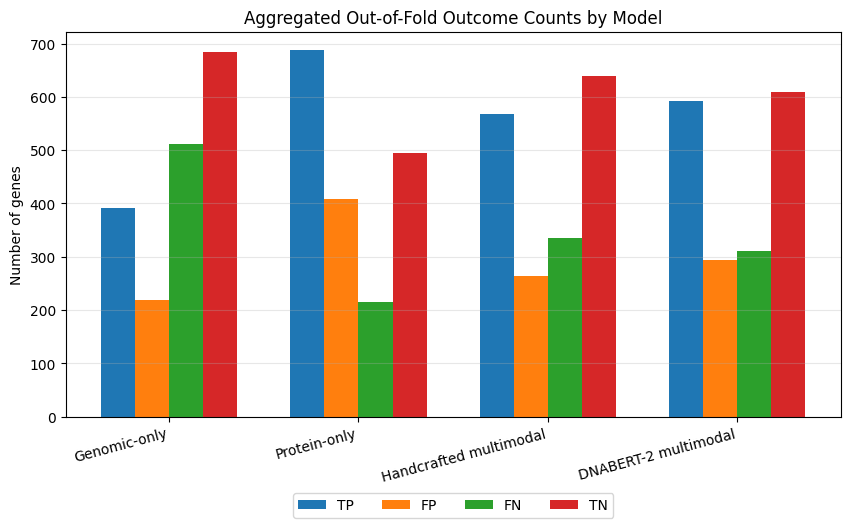

Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_oof_outcome_counts_by_model.png


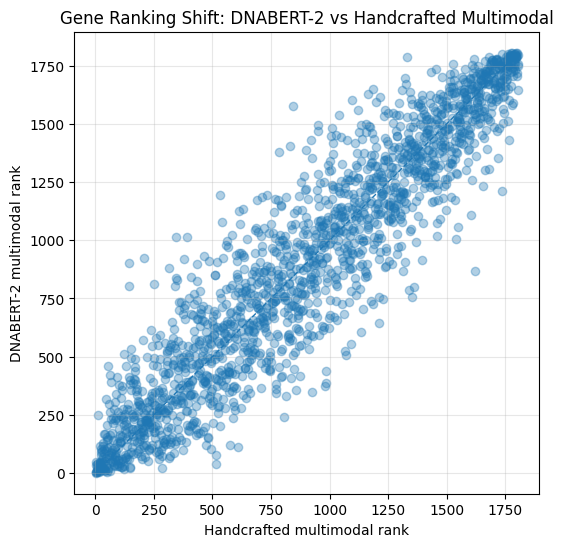

Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_dnabert2_vs_handcrafted_rank_scatter.png


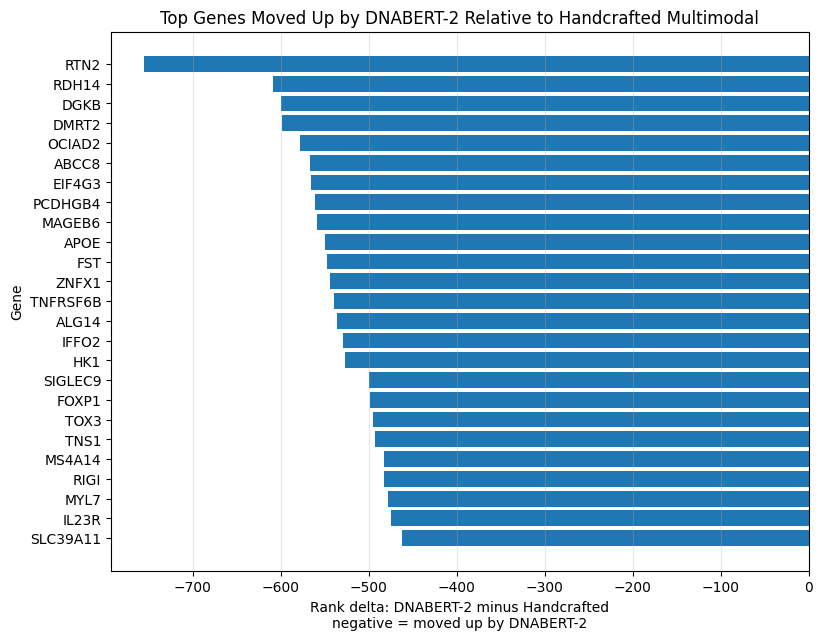

Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_top_genes_moved_up_by_dnabert2.png


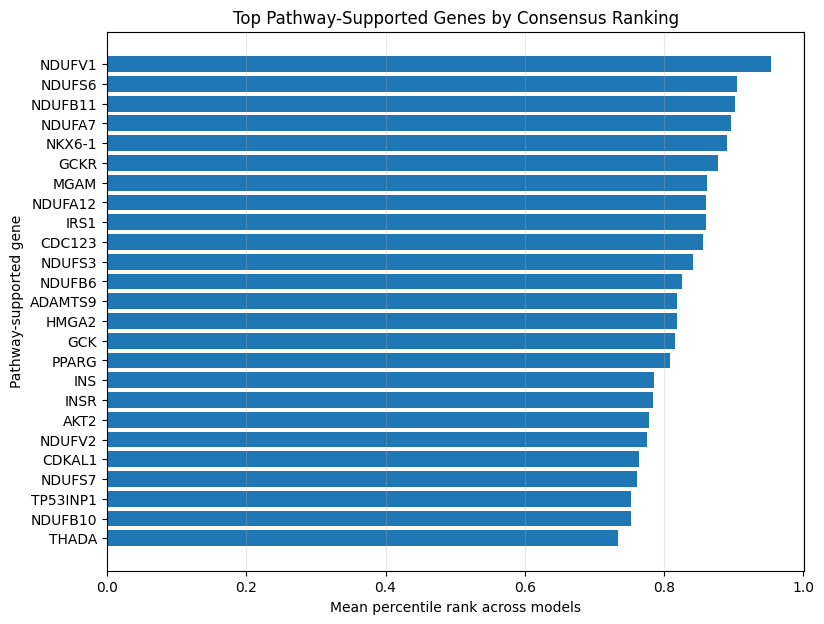

Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_top_pathway_supported_case_genes.png


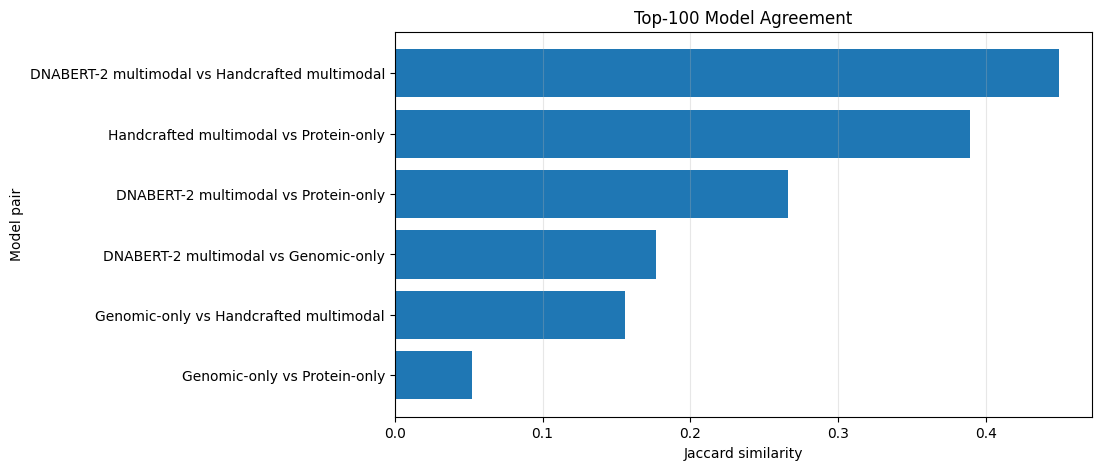

Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_top100_model_agreement_jaccard.png


In [11]:
# ============================================================
# FIGURE 1 — OUTCOME SUMMARY BY MODEL
# ============================================================

plot_df = outcome_summary_df.copy()

model_order = [
    "Genomic-only",
    "Protein-only",
    "Handcrafted multimodal",
    "DNABERT-2 multimodal"
]

outcome_order = ["TP", "FP", "FN", "TN"]

x = np.arange(len(model_order))
width = 0.18

plt.figure(figsize=(10, 5))

for i, outcome in enumerate(outcome_order):
    values = []
    for model in model_order:
        row = plot_df[
            (plot_df["display_name"] == model) &
            (plot_df["outcome"] == outcome)
        ]

        values.append(float(row["n_genes"].iloc[0]) if not row.empty else 0)

    plt.bar(
        x + (i - 1.5) * width,
        values,
        width=width,
        label=outcome
    )

plt.xticks(x, model_order, rotation=15, ha="right")
plt.ylabel("Number of genes")
plt.title("Aggregated Out-of-Fold Outcome Counts by Model")
plt.grid(axis="y", alpha=0.3)
plt.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))

out_path = FIGURE_DIR / "phase21_oof_outcome_counts_by_model.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ============================================================
# FIGURE 2 — DNABERT-2 VS HANDCRAFTED RANK SCATTER
# ============================================================

scatter_df = rank_shift_df.copy()

plt.figure(figsize=(6, 6))
plt.scatter(
    scatter_df["rank_desc__Handcrafted_multimodal"],
    scatter_df["rank_desc__DNABERT2_multimodal"],
    alpha=0.35
)
plt.plot(
    [1, scatter_df["rank_desc__Handcrafted_multimodal"].max()],
    [1, scatter_df["rank_desc__Handcrafted_multimodal"].max()],
    linestyle="--",
    linewidth=1
)
plt.xlabel("Handcrafted multimodal rank")
plt.ylabel("DNABERT-2 multimodal rank")
plt.title("Gene Ranking Shift: DNABERT-2 vs Handcrafted Multimodal")
plt.grid(alpha=0.3)

out_path = FIGURE_DIR / "phase21_dnabert2_vs_handcrafted_rank_scatter.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ============================================================
# FIGURE 3 — TOP GENES MOVED UP BY DNABERT-2
# ============================================================

plot_df = dnabert2_moved_up_df.head(25).copy()
plot_df = plot_df.sort_values("dnabert2_minus_handcrafted_rank_delta", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(
    plot_df["gene_symbol"][::-1],
    plot_df["dnabert2_minus_handcrafted_rank_delta"][::-1]
)
plt.xlabel("Rank delta: DNABERT-2 minus Handcrafted\nnegative = moved up by DNABERT-2")
plt.ylabel("Gene")
plt.title("Top Genes Moved Up by DNABERT-2 Relative to Handcrafted Multimodal")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase21_top_genes_moved_up_by_dnabert2.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ============================================================
# FIGURE 4 — TOP PATHWAY-SUPPORTED CASES
# ============================================================

plot_df = case_df[
    case_df["is_pathway_supported"] == True
].sort_values("consensus_rank").head(25).copy()

plt.figure(figsize=(9, 7))
plt.barh(
    plot_df["gene_symbol"][::-1],
    plot_df["mean_percentile_rank"][::-1]
)
plt.xlabel("Mean percentile rank across models")
plt.ylabel("Pathway-supported gene")
plt.title("Top Pathway-Supported Genes by Consensus Ranking")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase21_top_pathway_supported_case_genes.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ============================================================
# FIGURE 5 — MODEL AGREEMENT TOP-K JACCARD
# ============================================================

plot_df = agreement_df.copy()
plot_df["pair"] = plot_df["model_a_display"] + " vs " + plot_df["model_b_display"]

selected_k = 100
plot_df = plot_df[plot_df["top_k"] == selected_k].sort_values("jaccard", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["pair"], plot_df["jaccard"])
plt.xlabel("Jaccard similarity")
plt.ylabel("Model pair")
plt.title(f"Top-{selected_k} Model Agreement")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / f"phase21_top{selected_k}_model_agreement_jaccard.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [12]:
# ============================================================
# MANUSCRIPT-READY COMPACT TABLES
# ============================================================

compact_case_table_df = gene_case_report_df[
    gene_case_report_df["found_in_candidate_universe"] == True
].copy()

compact_case_table_df = compact_case_table_df[[
    "gene_symbol",
    "true_label",
    "consensus_rank",
    "mean_percentile_rank",
    "best_rank",
    "n_curated_pathways",
    "curated_pathways",
    "n_external_sets",
    "relabel_audit_priority",
    "case_interpretation",
    "dnabert2_minus_handcrafted_rank_delta",
    "model_rank_summary"
]].sort_values("consensus_rank")

compact_case_table_df = round_numeric_columns(compact_case_table_df, 4)

display(compact_case_table_df)

save_df(
    compact_case_table_df,
    RESULT_DIR / "phase21_manuscript_gene_case_table.csv"
)


compact_rank_shift_table_df = rank_shift_df[
    (rank_shift_df["n_curated_pathways"].fillna(0).astype(int) > 0) |
    (rank_shift_df["n_external_sets"].fillna(0).astype(int) > 0)
].copy()

compact_rank_shift_table_df = compact_rank_shift_table_df.sort_values(
    "dnabert2_minus_handcrafted_rank_delta",
    ascending=True
).head(30)

compact_rank_shift_table_df = compact_rank_shift_table_df[[
    "gene_symbol",
    "true_label",
    "rank_desc__DNABERT2_multimodal",
    "rank_desc__Handcrafted_multimodal",
    "dnabert2_minus_handcrafted_rank_delta",
    "mean_oof_score__DNABERT2_multimodal",
    "mean_oof_score__Handcrafted_multimodal",
    "n_curated_pathways",
    "curated_pathways",
    "n_external_sets",
    "external_sets"
]]

compact_rank_shift_table_df = round_numeric_columns(compact_rank_shift_table_df, 4)

display(compact_rank_shift_table_df)

save_df(
    compact_rank_shift_table_df,
    RESULT_DIR / "phase21_manuscript_dnabert2_rank_shift_supported_genes.csv"
)

,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,n_curated_pathways,curated_pathways,n_external_sets,relabel_audit_priority,case_interpretation,dnabert2_minus_handcrafted_rank_delta,model_rank_summary
16,NDUFV1,0,22,0.9537,28,1,Mitochondrial_complex_I_OXPHOS,0,high,Current-negative but pathway-supported hypothesis candidate,67,"Handcrafted multimodal: rank 28, score 0.831; Protein-only: rank 77, score 0.779; DNABERT-2 multimodal: rank 95, score 0.809; Genomic-only: rank 138, score 0.656"
20,NDUFS6,1,90,0.9051,120,1,Mitochondrial_complex_I_OXPHOS,0,,Known/current-positive high-confidence recovery,-56,"Genomic-only: rank 120, score 0.663; DNABERT-2 multimodal: rank 151, score 0.783; Handcrafted multimodal: rank 207, score 0.745; Protein-only: rank 211, score 0.727"
19,NDUFB11,1,95,0.9012,55,1,Mitochondrial_complex_I_OXPHOS,0,,Known/current-positive high-confidence recovery,-40,"DNABERT-2 multimodal: rank 55, score 0.828; Handcrafted multimodal: rank 95, score 0.795; Protein-only: rank 167, score 0.740; Genomic-only: rank 400, score 0.576"
18,NDUFA7,1,107,0.8958,28,1,Mitochondrial_complex_I_OXPHOS,0,,Known/current-positive high-confidence recovery,-95,"DNABERT-2 multimodal: rank 28, score 0.853; Handcrafted multimodal: rank 123, score 0.779; Protein-only: rank 145, score 0.746; Genomic-only: rank 460, score 0.561"
10,NKX6-1,1,115,0.8900,23,1,Beta_cell_function_development,0,,Known/current-positive high-confidence recovery,-30,"DNABERT-2 multimodal: rank 23, score 0.855; Protein-only: rank 39, score 0.806; Handcrafted multimodal: rank 53, score 0.815; Genomic-only: rank 683, score 0.521"
3,GCKR,1,131,0.8769,6,2,Glucose_metabolism_transport; Known_T2D_GWAS_loci,0,,Known/current-positive high-confidence recovery,31,"Protein-only: rank 6, score 0.841; Handcrafted multimodal: rank 10, score 0.865; DNABERT-2 multimodal: rank 41, score 0.840; Genomic-only: rank 836, score 0.497"
17,NDUFA12,0,158,0.8600,30,1,Mitochondrial_complex_I_OXPHOS,0,high,Current-negative but pathway-supported hypothesis candidate,-181,"Genomic-only: rank 30, score 0.717; DNABERT-2 multimodal: rank 98, score 0.806; Handcrafted multimodal: rank 279, score 0.719; Protein-only: rank 608, score 0.603"
1,IRS1,1,159,0.8598,117,3,Glucose_metabolism_transport; Insulin_signalling; Known_T2D_GWAS_loci,0,,Known/current-positive high-confidence recovery,124,"Handcrafted multimodal: rank 117, score 0.781; Protein-only: rank 237, score 0.718; DNABERT-2 multimodal: rank 241, score 0.745; Genomic-only: rank 421, score 0.571"
28,CDC123,1,168,0.8558,48,1,Known_T2D_GWAS_loci,0,,Known/current-positive high-confidence recovery,-213,"Genomic-only: rank 48, score 0.701; DNABERT-2 multimodal: rank 61, score 0.824; Handcrafted multimodal: rank 274, score 0.721; Protein-only: rank 662, score 0.586"
29,ADAMTS9,1,229,0.8191,180,1,Known_T2D_GWAS_loci,0,,Lower-priority / background candidate,-24,"DNABERT-2 multimodal: rank 180, score 0.770; Protein-only: rank 186, score 0.735; Handcrafted multimodal: rank 204, score 0.746; Genomic-only: rank 740, score 0.512"


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_manuscript_gene_case_table.csv


,gene_symbol,true_label,rank_desc__DNABERT2_multimodal,rank_desc__Handcrafted_multimodal,dnabert2_minus_handcrafted_rank_delta,mean_oof_score__DNABERT2_multimodal,mean_oof_score__Handcrafted_multimodal,n_curated_pathways,curated_pathways,n_external_sets,external_sets
430,ABCC8,1,645,1212,-567,0.5938,0.3907,2,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca,0,
1133,HK1,0,1210,1737,-527,0.3796,0.1836,1,Glucose_metabolism_transport,0,
1721,NDUFS4,1,766,1112,-346,0.5486,0.4258,1,Mitochondrial_complex_I_OXPHOS,0,
1730,NDUFV2,1,149,482,-333,0.7829,0.6492,1,Mitochondrial_complex_I_OXPHOS,0,
995,TP53INP1,1,303,586,-283,0.7243,0.6143,1,Known_T2D_GWAS_loci,0,
105,CDC123,1,61,274,-213,0.8236,0.7208,1,Known_T2D_GWAS_loci,0,
889,THADA,1,415,628,-213,0.6774,0.6005,1,Known_T2D_GWAS_loci,0,
585,NDUFA12,0,98,279,-181,0.8060,0.7191,1,Mitochondrial_complex_I_OXPHOS,0,
1387,SLC5A2,1,1514,1684,-170,0.2748,0.2120,2,Glucose_metabolism_transport; Incretin_diabetes_pharmacology,0,
1713,NEUROD1,1,1125,1278,-153,0.4155,0.3674,1,Beta_cell_function_development,0,


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_manuscript_dnabert2_rank_shift_supported_genes.csv


In [13]:
# ============================================================
# MANUSCRIPT-READY WORDING
# ============================================================

# Extract notable examples
top_negative_cases = high_ranked_negative_df.head(5)["gene_symbol"].tolist()
top_recovered = recovered_positive_df.head(5)["gene_symbol"].tolist()

# Best DNABERT moved-up pathway-supported genes
moved_up_supported = compact_rank_shift_table_df.head(5)["gene_symbol"].tolist()

methods_text = """
To complement aggregate performance and pathway analyses, a case-level ranking and error audit was performed using out-of-fold predictions from repeated cross-validation. For each gene and model, prediction scores, threshold votes, aggregated prediction labels and model ranks were summarized. Genes were categorized as true positives, false positives, true negatives or false negatives based on their current binary labels and aggregated out-of-fold predictions. Consensus ranks across models were then combined with curated pathway annotations and external evidence labels to identify high-confidence recovered positives, high-ranked current negatives, possible false negatives and hypothesis-generating candidates. DNABERT-2 and handcrafted multimodal rankings were compared directly to identify genes whose ranking changed most strongly between genomic representation strategies.
""".strip()

results_text = f"""
The case-level audit showed that model behaviour was heterogeneous across biologically relevant genes. Several current-positive genes were consistently recovered with high consensus ranks, including {', '.join(top_recovered)}. In contrast, several high-ranked current-negative genes, including {', '.join(top_negative_cases)}, were annotated by pathway or external evidence and therefore should not be interpreted as ordinary false positives. DNABERT-2 changed the ranking of selected pathway-supported genes relative to handcrafted multimodal features; notable moved-up examples included {', '.join(moved_up_supported)}. These case-level results help explain why global pathway enrichment was modest while individual biologically plausible candidates still appeared near the top of the rankings.
""".strip()

discussion_text = """
The case-level analysis strengthens the explainability component of the framework by connecting aggregate model behaviour to individual gene-level outcomes. Because disease-gene labels are incomplete, false positives should be interpreted cautiously: high-ranked negative-labelled genes with pathway or external support may represent unknown positives, annotation-incomplete genes or hypothesis-generating candidates. Conversely, low-ranked current positives reveal model limitations and may reflect biological mechanisms not captured by sequence-derived protein or promoter representations. Therefore, the most defensible interpretation is not that the framework provides definitive disease classification, but that it provides an interpretable prioritization system whose predictions can be audited at the gene, pathway and model-comparison levels.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Case-Level Explainability and Error Audit", "text": methods_text},
    {"section": "Results - Gene-Level Ranking Behaviour", "text": results_text},
    {"section": "Discussion - Interpretable Prioritization Under Incomplete Labels", "text": discussion_text}
])

display(wording_df)

save_df(
    wording_df,
    RESULT_DIR / "phase21_manuscript_ready_wording.csv"
)

with open(REPORT_DIR / "phase21_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Case-Level Explainability and Error Audit,"To complement aggregate performance and pathway analyses, a case-level ranking and error audit was performed using out-of-fold predictions from repeated cross-validation. For each gene and model, prediction scores, threshold votes, aggregated prediction labels and model ranks were summarized. Genes were categorized as true positives, false positives, true negatives or false negatives based on their current binary labels and aggregated out-of-fold predictions. Consensus ranks across models we..."
1,Results - Gene-Level Ranking Behaviour,"The case-level audit showed that model behaviour was heterogeneous across biologically relevant genes. Several current-positive genes were consistently recovered with high consensus ranks, including ATP4B, VDR, ZC3H13, B4GALNT1, CACNA2D3. In contrast, several high-ranked current-negative genes, including NEXMIF, LRRIQ1, SMARCAD1, PNLIP, NDUFV1, were annotated by pathway or external evidence and therefore should not be interpreted as ordinary false positives. DNABERT-2 changed the ranking of ..."
2,Discussion - Interpretable Prioritization Under Incomplete Labels,"The case-level analysis strengthens the explainability component of the framework by connecting aggregate model behaviour to individual gene-level outcomes. Because disease-gene labels are incomplete, false positives should be interpreted cautiously: high-ranked negative-labelled genes with pathway or external support may represent unknown positives, annotation-incomplete genes or hypothesis-generating candidates. Conversely, low-ranked current positives reveal model limitations and may refl..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_manuscript_ready_wording.csv
Saved manuscript wording.


In [14]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase21_case_level_explainability_error_ranking_audit_tables.xlsx"

tables = {
    "Model_Case_Outcomes": model_case_df,
    "Outcome_Summary": outcome_summary_df,
    "Consensus_Case_Annotation": case_df,
    "Rank_Shift_All": rank_shift_df,
    "DNABERT2_Moved_Up": dnabert2_moved_up_df,
    "DNABERT2_Moved_Down": dnabert2_moved_down_df,
    "Recovered_Positives": recovered_positive_df,
    "High_Ranked_Negatives": high_ranked_negative_df,
    "Pathway_Supported_Neg": pathway_supported_negative_df,
    "External_Supported_Neg": external_supported_negative_df,
    "Low_Ranked_Positives": model_miss_positive_df,
    "Gene_Case_Report": gene_case_report_df,
    "Model_Agreement": agreement_df,
    "Manuscript_Case_Table": compact_case_table_df,
    "Manuscript_Rank_Shift": compact_rank_shift_table_df,
    "Wording": wording_df
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/excel/phase21_case_level_explainability_error_ranking_audit_tables.xlsx


In [15]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 21 COMPLETE ===")

print("\nOutcome summary:")
display(outcome_summary_df)

print("\nTop recovered positives:")
display(recovered_positive_df.head(30))

print("\nTop high-ranked current negatives:")
display(high_ranked_negative_df.head(30))

print("\nPathway-supported current negatives:")
display(pathway_supported_negative_df.head(30))

print("\nLow-ranked current positives / possible misses:")
display(model_miss_positive_df.head(30))

print("\nCurated gene case report:")
display(gene_case_report_df)

print("\nDNABERT-2 moved-up supported genes:")
display(compact_rank_shift_table_df.head(30))

print("\nModel agreement:")
display(agreement_df)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 21 COMPLETE ===

Outcome summary:


,model_name,display_name,outcome,n_genes,n_total,percentage
0,DNABERT2_multimodal,DNABERT-2 multimodal,FN,311,1806,17.220
1,DNABERT2_multimodal,DNABERT-2 multimodal,FP,293,1806,16.224
2,DNABERT2_multimodal,DNABERT-2 multimodal,TN,610,1806,33.776
3,DNABERT2_multimodal,DNABERT-2 multimodal,TP,592,1806,32.780
4,Genomic_only_K3K4Basic,Genomic-only,FN,512,1806,28.350
5,Genomic_only_K3K4Basic,Genomic-only,FP,218,1806,12.071
6,Genomic_only_K3K4Basic,Genomic-only,TN,685,1806,37.929
7,Genomic_only_K3K4Basic,Genomic-only,TP,391,1806,21.650
8,Handcrafted_multimodal,Handcrafted multimodal,FN,336,1806,18.605
9,Handcrafted_multimodal,Handcrafted multimodal,FP,264,1806,14.618



Top recovered positives:


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets_x,n_external_sets_x,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets_y,external_sets_y,n_external_sets,external_sets,relabel_audit_priority,external_evidence_strength,case_interpretation
0,386,ATP4B,1,0.99598,0.00469,8.25,1,1,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
1,560,VDR,1,0.99127,0.00878,16.75,1,2,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
2,454,ZC3H13,1,0.98795,0.01199,22.75,4,3,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
3,878,B4GALNT1,1,0.98463,0.01526,28.75,14,4,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
4,389,CACNA2D3,1,0.98102,0.01853,35.25,7,5,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
5,309,GMDS,1,0.97825,0.01655,40.25,5,6,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
6,1232,ETS1,1,0.97701,0.02146,42.50,13,7,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
7,1701,GRM8,1,0.97576,0.04626,44.75,2,8,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
8,534,FEZF1,1,0.97382,0.04352,48.25,5,9,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
10,1685,RBM27,1,0.97230,0.01958,51.00,6,11,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery



Top high-ranked current negatives:


...


DNABERT-2 moved-up supported genes:


,gene_symbol,true_label,rank_desc__DNABERT2_multimodal,rank_desc__Handcrafted_multimodal,dnabert2_minus_handcrafted_rank_delta,mean_oof_score__DNABERT2_multimodal,mean_oof_score__Handcrafted_multimodal,n_curated_pathways,curated_pathways,n_external_sets,external_sets
430,ABCC8,1,645,1212,-567,0.5938,0.3907,2,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca,0,
1133,HK1,0,1210,1737,-527,0.3796,0.1836,1,Glucose_metabolism_transport,0,
1721,NDUFS4,1,766,1112,-346,0.5486,0.4258,1,Mitochondrial_complex_I_OXPHOS,0,
1730,NDUFV2,1,149,482,-333,0.7829,0.6492,1,Mitochondrial_complex_I_OXPHOS,0,
995,TP53INP1,1,303,586,-283,0.7243,0.6143,1,Known_T2D_GWAS_loci,0,
105,CDC123,1,61,274,-213,0.8236,0.7208,1,Known_T2D_GWAS_loci,0,
889,THADA,1,415,628,-213,0.6774,0.6005,1,Known_T2D_GWAS_loci,0,
585,NDUFA12,0,98,279,-181,0.8060,0.7191,1,Mitochondrial_complex_I_OXPHOS,0,
1387,SLC5A2,1,1514,1684,-170,0.2748,0.2120,2,Glucose_metabolism_transport; Incretin_diabetes_pharmacology,0,
1713,NEUROD1,1,1125,1278,-153,0.4155,0.3674,1,Beta_cell_function_development,0,



Model agreement:


,top_k,model_a,model_a_display,model_b,model_b_display,n_overlap,jaccard,overlap_genes
0,50,DNABERT2_multimodal,DNABERT-2 multimodal,Genomic_only_K3K4Basic,Genomic-only,7,0.07527,AKAP11; ATP4B; B4GALNT1; DTYMK; HCN4; VDR; ZC3H13
1,50,DNABERT2_multimodal,DNABERT-2 multimodal,Handcrafted_multimodal,Handcrafted multimodal,30,0.42857,ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; COLGALT1; DENND2A; DNAH11; EBAG9; EMILIN2; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HHIPL1; LRMDA; LRRIQ1; METTL25B; MLXIPL; NEXMIF; NSD3; PNLIP; RBM27; SEPTIN4; THEMIS; VDR; ZC3H13; ZNF747
2,50,DNABERT2_multimodal,DNABERT-2 multimodal,Protein_only_ProtBERT_SW,Protein-only,21,0.26582,ATP13A1; ATP4B; BMAL1; CACNA2D3; COLGALT1; EBAG9; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; JAG1; METTL25B; MLXIPL; NEXMIF; NKX6-1; THEMIS; VDR; ZC3H13; ZNF747
3,50,Genomic_only_K3K4Basic,Genomic-only,Handcrafted_multimodal,Handcrafted multimodal,5,0.05263,ATP4B; B4GALNT1; COBLL1; VDR; ZC3H13
4,50,Genomic_only_K3K4Basic,Genomic-only,Protein_only_ProtBERT_SW,Protein-only,3,0.03093,ATP4B; VDR; ZC3H13
5,50,Handcrafted_multimodal,Handcrafted multimodal,Protein_only_ProtBERT_SW,Protein-only,26,0.35135,ATP13A1; ATP4B; BMAL1; CACNA2D3; CCDC188; COLGALT1; EBAG9; ETS1; FEZF1; GCKR; GMDS; GPC5; GRM8; HAUS6; KCNK16; MARCHF10; METTL25B; MLXIPL; NEXMIF; PRSS37; SLC2A7; THEMIS; TOGARAM1; VDR; ZC3H13; ZNF747
6,100,DNABERT2_multimodal,DNABERT-2 multimodal,Genomic_only_K3K4Basic,Genomic-only,30,0.17647,AKAP11; ATP4B; B4GALNT1; CACNA2D3; CAPN10; CDC123; COQ5; DENND2A; DNAH11; DNMT3A; DTYMK; ETS1; FABP9; GMDS; HCN4; KMT5B; MTOR; NBPF3; NDUFA12; P2RY12; PLA2G3; PNLIP; RBM27; RNF216; SMARCAD1; TAF11L9; TAF2; VDR; ZC3H12C; ZC3H13
7,100,DNABERT2_multimodal,DNABERT-2 multimodal,Handcrafted_multimodal,Handcrafted multimodal,62,0.44928,ACADS; AOC1; ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; CCDC188; CCDC57; COLGALT1; DENND2A; DNAH11; DTYMK; EBAG9; EMILIN2; EML5; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HCN4; HHIPL1; HMGCR; IGF2BP3; JAG1; KMT5B; LRMDA; LRRC74A; LRRIQ1; METTL25B; MLXIPL; NDUFB11; NDUFV1; NEXMIF; NKX6-1; NSD3; OCRL; PHGDH; PLA2G3; PNLIP; RAET1L; RBM27; RGS18; RLF; SEPTIN4; SLC2A7; SMARCAD1; SSX5; TAF11L9; TAF2; THEMIS; TLCD4; TNRC6A; TSC22D2; VDR; ZC3H12C; ZC3H13; ZNF329; ZNF462; ZNF747
8,100,DNABERT2_multimodal,DNABERT-2 multimodal,Protein_only_ProtBERT_SW,Protein-only,42,0.26582,ACADS; APOL5; ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; CCDC188; COLGALT1; DTYMK; EBAG9; EMILIN2; EML5; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HHIPL1; HMGA1; JAG1; LRRC74A; LRRIQ1; METTL25B; MLXIPL; MYO5C; NBPF9; NDUFV1; NEXMIF; NKX6-1; RBM27; RGS18; SEPTIN4; SLC2A7; SMARCAD1; THEMIS; VDR; VWA5B1; ZC3H13; ZNF462; ZNF747
9,100,Genomic_only_K3K4Basic,Genomic-only,Handcrafted_multimodal,Handcrafted multimodal,27,0.15607,ATP4B; B4GALNT1; CACNA2D3; CDH24; CLIC5; COBLL1; DENND2A; DNAH11; DTYMK; ETS1; GMDS; HCN4; IL17REL; KMT5B; OSBPL5; PACRG; PLA2G3; PNLIP; RBM27; SEC14L3; SMARCAD1; SYTL2; TAF11L9; TAF2; VDR; ZC3H12C; ZC3H13



Figures:
/content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_dnabert2_vs_handcrafted_rank_scatter.png
/content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_oof_outcome_counts_by_model.png
/content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_top100_model_agreement_jaccard.png
/content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_top_genes_moved_up_by_dnabert2.png
/content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/figures/phase21_top_pathway_supported_case_genes.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainability_error_ranking_audit/results/phase21_consensus_case_annotation_table.csv
/content/drive/MyDrive/Project_Protein/model/phase21_case_level_explainabi

In [16]:
display(outcome_summary_df)

display(gene_case_report_df)

display(compact_rank_shift_table_df.head(30))

display(recovered_positive_df.head(30))

display(high_ranked_negative_df.head(30))

display(model_miss_positive_df.head(30))

display(agreement_df)

,model_name,display_name,outcome,n_genes,n_total,percentage
0,DNABERT2_multimodal,DNABERT-2 multimodal,FN,311,1806,17.220
1,DNABERT2_multimodal,DNABERT-2 multimodal,FP,293,1806,16.224
2,DNABERT2_multimodal,DNABERT-2 multimodal,TN,610,1806,33.776
3,DNABERT2_multimodal,DNABERT-2 multimodal,TP,592,1806,32.780
4,Genomic_only_K3K4Basic,Genomic-only,FN,512,1806,28.350
5,Genomic_only_K3K4Basic,Genomic-only,FP,218,1806,12.071
6,Genomic_only_K3K4Basic,Genomic-only,TN,685,1806,37.929
7,Genomic_only_K3K4Basic,Genomic-only,TP,391,1806,21.650
8,Handcrafted_multimodal,Handcrafted multimodal,FN,336,1806,18.605
9,Handcrafted_multimodal,Handcrafted multimodal,FP,264,1806,14.618


,gene_symbol,found_in_candidate_universe,true_label,consensus_rank,mean_percentile_rank,best_rank,n_curated_pathways,curated_pathways,n_external_sets,external_sets,relabel_audit_priority,case_interpretation,dnabert2_minus_handcrafted_rank_delta,dnabert2_minus_handcrafted_score_delta,model_rank_summary
0,INSR,True,1,290,0.78476,162,4,Glucose_metabolism_transport; Incretin_diabetes_pharmacology; Insulin_signalling; Known_T2D_GWAS_loci,0,,,Lower-priority / background candidate,-68,0.02730,"Genomic-only: rank 162, score 0.647; DNABERT-2 multimodal: rank 395, score 0.684; Handcrafted multimodal: rank 463, score 0.656; Protein-only: rank 538, score 0.625"
1,IRS1,True,1,159,0.85983,117,3,Glucose_metabolism_transport; Insulin_signalling; Known_T2D_GWAS_loci,0,,,Known/current-positive high-confidence recovery,124,-0.03588,"Handcrafted multimodal: rank 117, score 0.781; Protein-only: rank 237, score 0.718; DNABERT-2 multimodal: rank 241, score 0.745; Genomic-only: rank 421, score 0.571"
2,GCK,True,1,236,0.81565,98,5,Beta_cell_function_development; Glucose_metabolism_transport; Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca; Known_T2D_GWAS_loci,0,,,Lower-priority / background candidate,-45,0.02845,"Protein-only: rank 98, score 0.766; DNABERT-2 multimodal: rank 256, score 0.741; Handcrafted multimodal: rank 301, score 0.713; Genomic-only: rank 680, score 0.521"
3,GCKR,True,1,131,0.87687,6,2,Glucose_metabolism_transport; Known_T2D_GWAS_loci,0,,,Known/current-positive high-confidence recovery,31,-0.02512,"Protein-only: rank 6, score 0.841; Handcrafted multimodal: rank 10, score 0.865; DNABERT-2 multimodal: rank 41, score 0.840; Genomic-only: rank 836, score 0.497"
4,DPP4,True,0,1515,0.21648,1322,1,Incretin_diabetes_pharmacology,0,,low,Lower-priority / background candidate,-4,-0.01255,"Genomic-only: rank 1322, score 0.434; DNABERT-2 multimodal: rank 1438, score 0.301; Handcrafted multimodal: rank 1442, score 0.313; Protein-only: rank 1459, score 0.311"
5,GIPR,True,0,413,0.72548,348,3,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca; Known_T2D_GWAS_loci,0,,high,Current-negative but pathway-supported hypothesis candidate,-48,0.02140,"Protein-only: rank 348, score 0.686; DNABERT-2 multimodal: rank 408, score 0.680; Handcrafted multimodal: rank 456, score 0.658; Genomic-only: rank 774, score 0.506"
6,KCNJ11,True,1,1081,0.41620,724,3,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca; Known_T2D_GWAS_loci,0,,,Current-positive low-rank / possible model miss,-86,0.02112,"Genomic-only: rank 724, score 0.514; Protein-only: rank 1037, score 0.459; DNABERT-2 multimodal: rank 1186, score 0.392; Handcrafted multimodal: rank 1272, score 0.371"
7,ABCC8,True,1,864,0.51981,543,2,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca,0,,,Lower-priority / background candidate,-567,0.20316,"Genomic-only: rank 543, score 0.546; DNABERT-2 multimodal: rank 645, score 0.594; Protein-only: rank 1071, score 0.448; Handcrafted multimodal: rank 1212, score 0.391"
8,PDX1,True,1,1091,0.41136,668,1,Beta_cell_function_development,0,,,Current-positive low-rank / possible model miss,147,-0.06027,"Genomic-only: rank 668, score 0.525; Handcrafted multimodal: rank 1121, score 0.422; Protein-only: rank 1197, score 0.408; DNABERT-2 multimodal: rank 1268, score 0.361"
9,NEUROD1,True,1,1105,0.40485,131,1,Beta_cell_function_development,0,,,Current-positive low-rank / possible model miss,-153,0.04813,"Genomic-only: rank 131, score 0.659; DNABERT-2 multimodal: rank 1125, score 0.415; Handcrafted multimodal: rank 1278, score 0.367; Protein-only: rank 1767, score 0.190"


,gene_symbol,true_label,rank_desc__DNABERT2_multimodal,rank_desc__Handcrafted_multimodal,dnabert2_minus_handcrafted_rank_delta,mean_oof_score__DNABERT2_multimodal,mean_oof_score__Handcrafted_multimodal,n_curated_pathways,curated_pathways,n_external_sets,external_sets
430,ABCC8,1,645,1212,-567,0.5938,0.3907,2,Incretin_diabetes_pharmacology; Insulin_secretion_KATP_Ca,0,
1133,HK1,0,1210,1737,-527,0.3796,0.1836,1,Glucose_metabolism_transport,0,
1721,NDUFS4,1,766,1112,-346,0.5486,0.4258,1,Mitochondrial_complex_I_OXPHOS,0,
1730,NDUFV2,1,149,482,-333,0.7829,0.6492,1,Mitochondrial_complex_I_OXPHOS,0,
995,TP53INP1,1,303,586,-283,0.7243,0.6143,1,Known_T2D_GWAS_loci,0,
105,CDC123,1,61,274,-213,0.8236,0.7208,1,Known_T2D_GWAS_loci,0,
889,THADA,1,415,628,-213,0.6774,0.6005,1,Known_T2D_GWAS_loci,0,
585,NDUFA12,0,98,279,-181,0.8060,0.7191,1,Mitochondrial_complex_I_OXPHOS,0,
1387,SLC5A2,1,1514,1684,-170,0.2748,0.2120,2,Glucose_metabolism_transport; Incretin_diabetes_pharmacology,0,
1713,NEUROD1,1,1125,1278,-153,0.4155,0.3674,1,Beta_cell_function_development,0,


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets_x,n_external_sets_x,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets_y,external_sets_y,n_external_sets,external_sets,relabel_audit_priority,external_evidence_strength,case_interpretation
0,386,ATP4B,1,0.99598,0.00469,8.25,1,1,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
1,560,VDR,1,0.99127,0.00878,16.75,1,2,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
2,454,ZC3H13,1,0.98795,0.01199,22.75,4,3,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
3,878,B4GALNT1,1,0.98463,0.01526,28.75,14,4,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
4,389,CACNA2D3,1,0.98102,0.01853,35.25,7,5,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
5,309,GMDS,1,0.97825,0.01655,40.25,5,6,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
6,1232,ETS1,1,0.97701,0.02146,42.50,13,7,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
7,1701,GRM8,1,0.97576,0.04626,44.75,2,8,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
8,534,FEZF1,1,0.97382,0.04352,48.25,5,9,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery
10,1685,RBM27,1,0.97230,0.01958,51.00,6,11,NaN,0,False,0,,False,NaN,NaN,0,,,,Known/current-positive high-confidence recovery


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets_x,n_external_sets_x,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets_y,external_sets_y,n_external_sets,external_sets,relabel_audit_priority,external_evidence_strength,case_interpretation
9,21,NEXMIF,0,0.97258,0.05227,50.50,1,10,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
14,1014,LRRIQ1,0,0.96759,0.02861,59.50,13,14,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
15,612,SMARCAD1,0,0.96385,0.01370,66.25,38,16,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
19,1161,PNLIP,0,0.95540,0.04730,81.50,7,20,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
21,268,NDUFV1,0,0.95374,0.02523,84.50,28,22,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,high,single_source,Current-negative but pathway-supported hypothesis candidate
22,401,SEPTIN4,0,0.95291,0.03932,86.00,30,23,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
34,702,KMT5B,0,0.94404,0.03965,102.00,45,35,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
37,277,LRMDA,0,0.94238,0.06299,105.00,19,38,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
63,1054,IGF2BP3,0,0.92313,0.06227,139.75,29,64,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit
66,1258,ZC3H12C,0,0.92202,0.06693,141.75,71,67,NaN,0,False,0,,False,NaN,NaN,0,,,,High-ranked current-negative candidate requiring audit


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets_x,n_external_sets_x,is_external_supported,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets_y,external_sets_y,n_external_sets,external_sets,relabel_audit_priority,external_evidence_strength,case_interpretation
1805,1737,TRAF3IP2,1,0.00637,0.00684,1794.50,1777,1806,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1801,1502,NDUFAF3,1,0.01939,0.02399,1771.00,1707,1802,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1798,787,ZNF573,1,0.02161,0.00412,1767.00,1760,1799,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1791,791,TIMP4,1,0.02978,0.05476,1752.25,1604,1792,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1786,715,NTNG1,1,0.03864,0.04640,1736.25,1619,1787,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1751,352,RAB27B,1,0.07465,0.00719,1671.25,1653,1752,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1750,438,PCDHGA8,1,0.07521,0.08887,1670.25,1432,1751,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1730,1706,NDUFB2,1,0.08906,0.08021,1645.25,1434,1731,Mitochondrial_OXPHOS_complex_I,1,False,1,Mitochondrial_complex_I_OXPHOS,True,1.0,Mitochondrial_OXPHOS_complex_I,0,,,,Current-positive low-rank / possible model miss
1722,770,CFAP47,1,0.09862,0.10044,1628.00,1359,1723,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss
1721,1692,BRWD3,1,0.09972,0.06513,1626.00,1503,1722,NaN,0,False,0,,False,NaN,NaN,0,,,,Current-positive low-rank / possible model miss


,top_k,model_a,model_a_display,model_b,model_b_display,n_overlap,jaccard,overlap_genes
0,50,DNABERT2_multimodal,DNABERT-2 multimodal,Genomic_only_K3K4Basic,Genomic-only,7,0.07527,AKAP11; ATP4B; B4GALNT1; DTYMK; HCN4; VDR; ZC3H13
1,50,DNABERT2_multimodal,DNABERT-2 multimodal,Handcrafted_multimodal,Handcrafted multimodal,30,0.42857,ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; COLGALT1; DENND2A; DNAH11; EBAG9; EMILIN2; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HHIPL1; LRMDA; LRRIQ1; METTL25B; MLXIPL; NEXMIF; NSD3; PNLIP; RBM27; SEPTIN4; THEMIS; VDR; ZC3H13; ZNF747
2,50,DNABERT2_multimodal,DNABERT-2 multimodal,Protein_only_ProtBERT_SW,Protein-only,21,0.26582,ATP13A1; ATP4B; BMAL1; CACNA2D3; COLGALT1; EBAG9; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; JAG1; METTL25B; MLXIPL; NEXMIF; NKX6-1; THEMIS; VDR; ZC3H13; ZNF747
3,50,Genomic_only_K3K4Basic,Genomic-only,Handcrafted_multimodal,Handcrafted multimodal,5,0.05263,ATP4B; B4GALNT1; COBLL1; VDR; ZC3H13
4,50,Genomic_only_K3K4Basic,Genomic-only,Protein_only_ProtBERT_SW,Protein-only,3,0.03093,ATP4B; VDR; ZC3H13
5,50,Handcrafted_multimodal,Handcrafted multimodal,Protein_only_ProtBERT_SW,Protein-only,26,0.35135,ATP13A1; ATP4B; BMAL1; CACNA2D3; CCDC188; COLGALT1; EBAG9; ETS1; FEZF1; GCKR; GMDS; GPC5; GRM8; HAUS6; KCNK16; MARCHF10; METTL25B; MLXIPL; NEXMIF; PRSS37; SLC2A7; THEMIS; TOGARAM1; VDR; ZC3H13; ZNF747
6,100,DNABERT2_multimodal,DNABERT-2 multimodal,Genomic_only_K3K4Basic,Genomic-only,30,0.17647,AKAP11; ATP4B; B4GALNT1; CACNA2D3; CAPN10; CDC123; COQ5; DENND2A; DNAH11; DNMT3A; DTYMK; ETS1; FABP9; GMDS; HCN4; KMT5B; MTOR; NBPF3; NDUFA12; P2RY12; PLA2G3; PNLIP; RBM27; RNF216; SMARCAD1; TAF11L9; TAF2; VDR; ZC3H12C; ZC3H13
7,100,DNABERT2_multimodal,DNABERT-2 multimodal,Handcrafted_multimodal,Handcrafted multimodal,62,0.44928,ACADS; AOC1; ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; CCDC188; CCDC57; COLGALT1; DENND2A; DNAH11; DTYMK; EBAG9; EMILIN2; EML5; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HCN4; HHIPL1; HMGCR; IGF2BP3; JAG1; KMT5B; LRMDA; LRRC74A; LRRIQ1; METTL25B; MLXIPL; NDUFB11; NDUFV1; NEXMIF; NKX6-1; NSD3; OCRL; PHGDH; PLA2G3; PNLIP; RAET1L; RBM27; RGS18; RLF; SEPTIN4; SLC2A7; SMARCAD1; SSX5; TAF11L9; TAF2; THEMIS; TLCD4; TNRC6A; TSC22D2; VDR; ZC3H12C; ZC3H13; ZNF329; ZNF462; ZNF747
8,100,DNABERT2_multimodal,DNABERT-2 multimodal,Protein_only_ProtBERT_SW,Protein-only,42,0.26582,ACADS; APOL5; ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; CCDC188; COLGALT1; DTYMK; EBAG9; EMILIN2; EML5; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HHIPL1; HMGA1; JAG1; LRRC74A; LRRIQ1; METTL25B; MLXIPL; MYO5C; NBPF9; NDUFV1; NEXMIF; NKX6-1; RBM27; RGS18; SEPTIN4; SLC2A7; SMARCAD1; THEMIS; VDR; VWA5B1; ZC3H13; ZNF462; ZNF747
9,100,Genomic_only_K3K4Basic,Genomic-only,Handcrafted_multimodal,Handcrafted multimodal,27,0.15607,ATP4B; B4GALNT1; CACNA2D3; CDH24; CLIC5; COBLL1; DENND2A; DNAH11; DTYMK; ETS1; GMDS; HCN4; IL17REL; KMT5B; OSBPL5; PACRG; PLA2G3; PNLIP; RBM27; SEC14L3; SMARCAD1; SYTL2; TAF11L9; TAF2; VDR; ZC3H12C; ZC3H13
